# 4 — Multivariate (vector-valued) registration

The original Dorn et al. (2012) data contain all three ground reaction force components
(anteroposterior, vertical, mediolateral) for 18 trials at four running speeds. Registering the
three components *jointly* — one warp per trial, chosen so that all three components are aligned
at once — is preferable to registering them separately (which would give three different time
axes for the same trial) or to registering on one component and hoping the others follow.

`register_srsf` accepts a (J,Q,D) array and then uses the vector SRSF
q = f′ / √‖f′‖ (Srivastava et al. 2011; the same dynamic programming applies, with the
squared Euclidean norm of the D-dimensional difference in the segment costs).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so that this notebook finds reg1d without installation
import numpy as np
from matplotlib import pyplot as plt
import reg1d
print('reg1d version:', reg1d.__version__)

reg1d version: 0.0.2


Dataset: Dorn2012MV
    J = 18
    speeds = [3.56, 5.2, 7.0, 9.49]



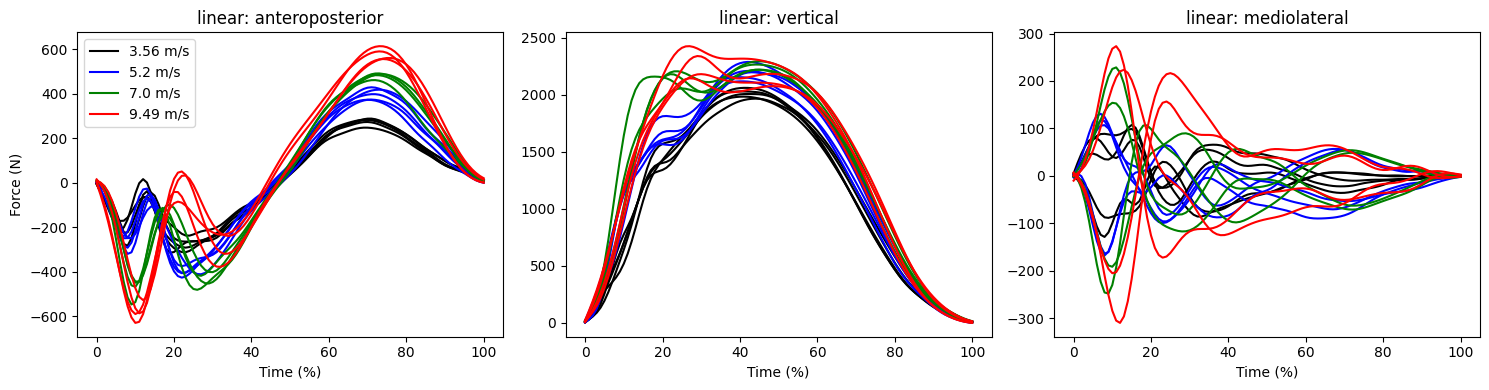

In [2]:
dataset = reg1d.data.Dorn2012MV()
print(dataset)
Y       = dataset.resample(101)            # (18,101,3): linear registration of every component
speed   = dataset.group                    # 0..3
comps   = dataset.components
colors  = ['k','b','g','r']

def plot3(Y, title, axes=None):
    fig,AX = plt.subplots(1, 3, figsize=(15,4)) if axes is None else (None, axes)
    for k,ax in enumerate(AX):
        reg1d.plot.plot_curves(Y[:,:,k], group=speed, ax=ax, colors=colors, x='percent', legend=(k==0),
                               labels=[f'{v} m/s' for v in np.unique(dataset.speed)])
        ax.set_title(f'{title}: {comps[k]}'); ax.set_xlabel('Time (%)')
    AX[0].set_ylabel('Force (N)')
    return AX

plot3(Y, 'linear'); plt.tight_layout(); plt.show()

### Joint (multivariate) SRSF registration

NonlinearRegistrationResult (srsf)
    y        : (18, 101, 3)
    warps    : (18, 101)
    t        : [0, 1] (101 points)
    template : (101, 3)
    islinear : False
    info     : ['niter', 'cost', 'q']



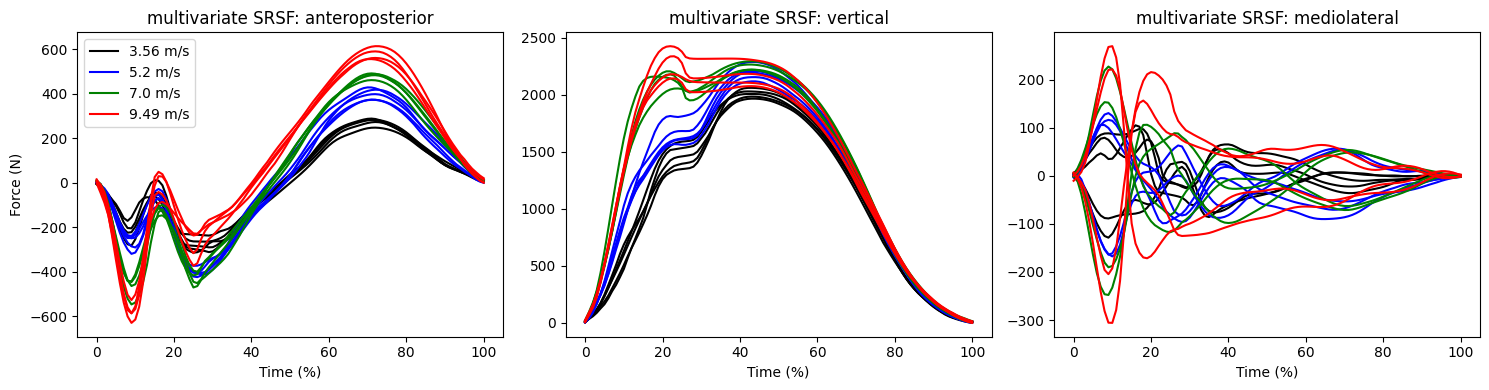

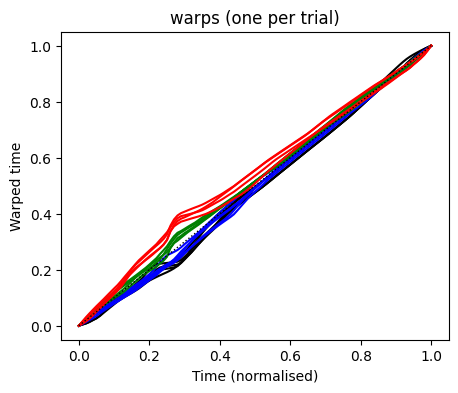

In [3]:
res_mv = reg1d.register_srsf(Y, max_iter=5)
print(res_mv)
plot3(res_mv.y, 'multivariate SRSF'); plt.tight_layout(); plt.show()
fig,ax = plt.subplots(figsize=(5,4))
res_mv.warps.plot(ax=ax, group=speed, colors=colors, legend=False); ax.set_title('warps (one per trial)')
plt.show()

### Comparison with univariate registration on each component

Registering each component separately gives three different warps per trial (and therefore
three inconsistent time axes); registering on one component only (here the vertical force,
the usual choice) and applying its warps to the others (`result.apply`) keeps one time axis but
aligns the other components only insofar as their features co-occur with those of the driving
component.

SD (% stance) of event times [AP peak, vertical 50%-rise, ML |peak|]
  linear only             [1.84, 1.77, 4.37]
  multivariate SRSF       [0.6, 3.03, 3.39]
  vertical-driven warps   [0.81, 0.76, 6.35]
  separate per component  [0.23, 0.76, 8.36]   (three different time axes per trial)


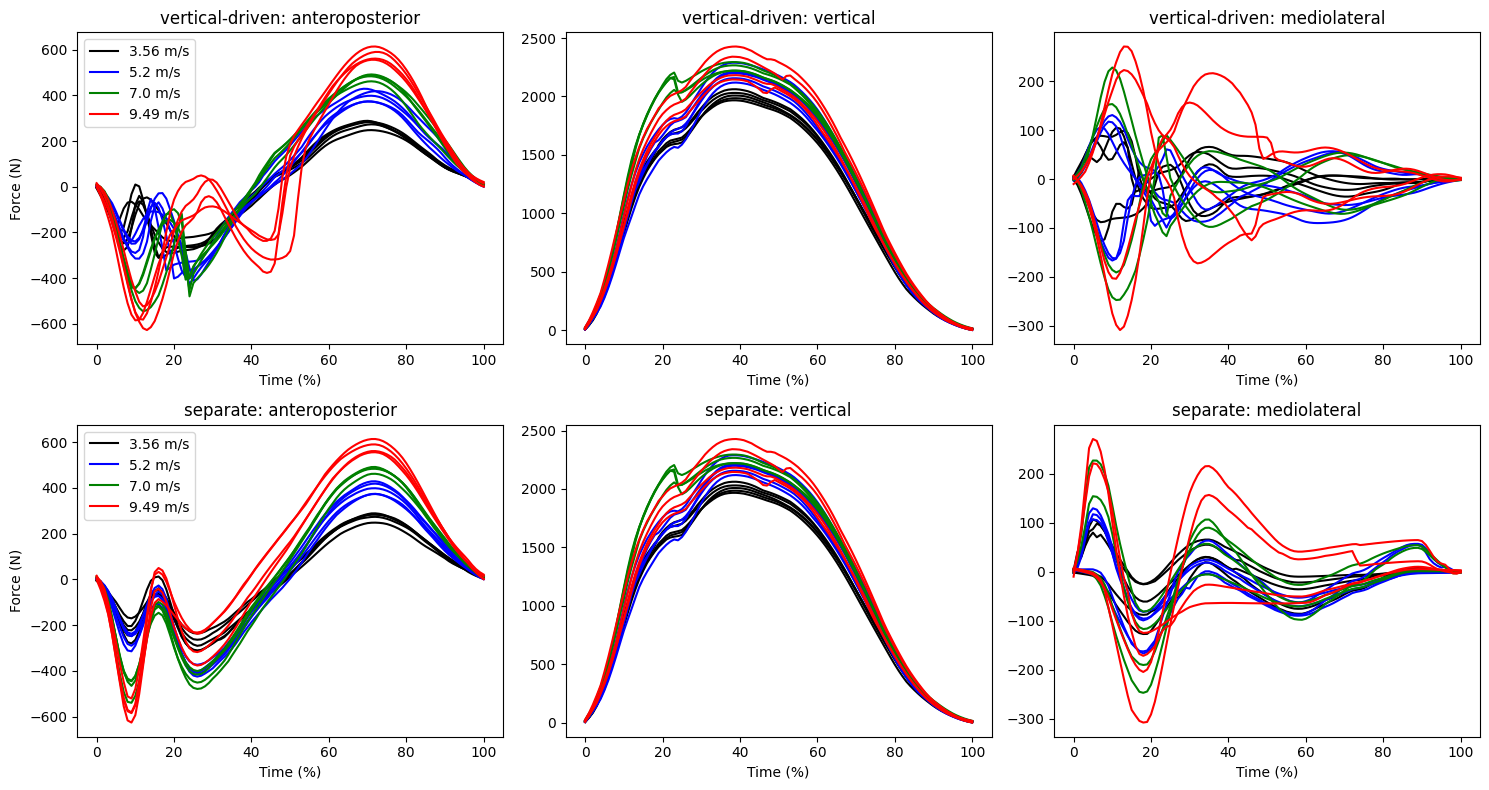

In [4]:
res_v   = reg1d.register_srsf(Y[:,:,1], max_iter=5)          # vertical only
Y_from_v = res_v.apply(Y)                                    # apply vertical warps to all components
res_sep = [reg1d.register_srsf(Y[:,:,k], max_iter=5) for k in range(3)]
Y_sep   = np.stack([r.y for r in res_sep], axis=2)

def event_sd(Y):
    # SD (in % stance) of three event times: AP propulsive peak, vertical rising edge (50% of max), ML largest |F|
    ap = np.argmax(Y[:,:,0], axis=1)
    v  = np.array([np.argmax(yy > 0.5*yy.max()) for yy in Y[:,:,1]])
    ml = np.argmax(np.abs(Y[:,:,2]), axis=1)
    return [float(np.std(e).round(2)) for e in (ap, v, ml)]
print('SD (% stance) of event times [AP peak, vertical 50%-rise, ML |peak|]')
print('  linear only            ', event_sd(Y))
print('  multivariate SRSF      ', event_sd(res_mv.y))
print('  vertical-driven warps  ', event_sd(Y_from_v))
print('  separate per component ', event_sd(Y_sep), '  (three different time axes per trial)')
fig,AX = plt.subplots(2, 3, figsize=(15,8))
plot3(Y_from_v, 'vertical-driven', AX[0]); plot3(Y_sep, 'separate', AX[1])
plt.tight_layout(); plt.show()

The joint registration is the only approach that yields a single, physically consistent time
axis per trial while using the information in all three components — but a single warp per
trial is necessarily a compromise between the components: in the table above the joint warps
align the anteroposterior peak much better than linear registration, while the vertical rising
edge is aligned less well than when the vertical component alone drives the warps. Which
compromise is right depends on the research question. Note also that the vector SRSF weights
components by their slopes, so the large vertical force dominates and the small mediolateral
component contributes little; rescaling components (e.g. to unit variance) before registration
changes this weighting and may be desirable when the components have very different magnitudes.